In [32]:
%load_ext autoreload
%autoreload 2

import time
from typing import Tuple
import random

import numpy as np
import matplotlib.pyplot as plt
import torch as th
from torch.utils.data import DataLoader
from torch.nn import functional as F
from torchvision import datasets, transforms
from torchvision.utils import make_grid

from mmidas.nn_model import mk_vae
from mmidas.model import Net
from mmidas.train import generic_train
from mmidas._data_util import load_data, viz
from mmidas._utils import sample, unzip

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [14]:
sample([1, 2, 3], 100)

[2,
 1,
 2,
 2,
 1,
 2,
 1,
 3,
 2,
 3,
 3,
 2,
 2,
 1,
 2,
 1,
 3,
 3,
 1,
 2,
 3,
 1,
 1,
 2,
 2,
 1,
 3,
 2,
 1,
 3,
 3,
 1,
 3,
 1,
 3,
 3,
 1,
 1,
 2,
 3,
 2,
 3,
 1,
 2,
 3,
 2,
 3,
 1,
 1,
 2,
 2,
 2,
 3,
 2,
 1,
 2,
 2,
 2,
 1,
 2,
 1,
 3,
 3,
 2,
 2,
 2,
 1,
 1,
 3,
 3,
 3,
 1,
 2,
 1,
 2,
 3,
 1,
 3,
 3,
 3,
 2,
 1,
 1,
 2,
 1,
 2,
 1,
 3,
 3,
 2,
 3,
 3,
 1,
 1,
 2,
 1,
 1,
 1,
 2,
 2]

In [26]:
train_loader, val_loader, test_loader = load_data('mnist', batch_size=64)
xs_train, ys_train = unzip(list(train_loader))
xs_val, ys_val = unzip(list(val_loader))
xs_test, ys_test = unzip(list(test_loader))

TypeError: Invalid shape (64, 1, 28, 28) for image data

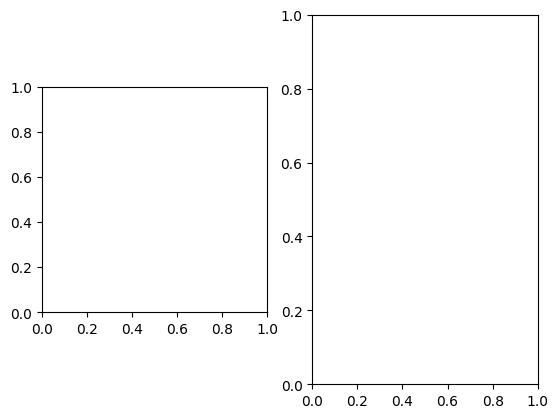

In [34]:
viz(sample(xs_train, 2))

In [48]:
net = Net()
opt = th.optim.SGD(net.parameters(), lr=1e-3)
metrics = generic_train(net, opt, train_loader, val_loader, epochs=10)

train completed in: 308.33s
final train loss: 0.3411
final train acc: 0.9062
final val loss: 0.0028
final val acc: 0.9449


In [48]:
device = 'cpu'
A = 5
model = mk_vae(10, 2, 784, A=A, device=device).to(device)

In [49]:
(x, y) = next(iter(train_loader))
x = x.to(device)
y = y.to(device)
x_recs, _, _, x_lows, cs, s_smps, c_smps, s_means, s_logvars, c_probs = model([x for _ in range(A)], 1)
cs = th.stack(cs)
cs.shape

torch.Size([5, 500, 10])

In [66]:
tic = time.time()
loss_naive = model.loss_naive(cs)
t1 = time.time() - tic

tic = time.time()
loss_vec = model.loss_vectorize(cs)
t2 = time.time() - tic

print(f"Naive loss: {loss_naive.item()}")
print(f"Vectorized loss: {loss_vec.item()}")
print(f"Relative error: {th.norm(loss_naive - loss_vec) / th.norm(loss_naive)}\n")


print(f"Naive loss computation took: {t1}s")
print(f"Vectorized loss computation took: {t2}s")
print(f"Speedup: {100 * (t1 - t2) / t1:.2f}%")

Naive loss: 71688.578125
Vectorized loss: 71688.5859375
Relative error: 1.0897830549083665e-07

Naive loss computation took: 0.003282785415649414s
Vectorized loss computation took: 0.0005891323089599609s
Speedup: 82.05%
